<a href="https://www.kaggle.com/code/sonawanelalitsunil/icc-women-s-odi-world-cup-2025-ml-42-82?scriptVersionId=273108558" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/icc-womens-cricket-odi-world-cup/match_records.csv
/kaggle/input/icc-womens-cricket-odi-world-cup/bowling_stats.csv
/kaggle/input/icc-womens-cricket-odi-world-cup/batting_stats.csv


## Title: 🏏 ICC Women’s Cricket ODI World Cup 2025 🏆

## Description:
The ICC Women’s Cricket ODI World Cup 2025 is the pinnacle of women’s one-day international cricket, bringing together the world’s top national teams to compete for the ultimate glory. Scheduled to be held under the governance of the International Cricket Council (ICC), this edition promises high-intensity matches, record-breaking performances, and inspiring stories of sportsmanship and determination. Fans can look forward to witnessing star players, emerging talents, and thrilling contests that celebrate the spirit and evolution of women’s cricket on the global stage.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/icc-womens-cricket-odi-world-cup/match_records.csv")

In [3]:
df.head()

,match_id,date,team1,team2,match_type,venue_stadium,venue_city,venue_country,toss_winner,toss_decision,...,2nd_score,2nd_wkts,DLS_involved,wb_runs,wb_wickets,POTM,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,30-09-2025,India,Sri Lanka,League Stage,Barsapara Cricket Stadium,Guwahati,India,Sri Lanka,bowl,...,211.0,10.0,Yes,59.0,NaN,Deepti Sharma,Amanjot Kaur,57.0,Inoka Ranaweera,4--46
1,2,01-10-2025,Australia,New Zealand,League Stage,Holkar Stadium,Indore,India,Australia,bat,...,237.0,10.0,No,89.0,NaN,Ashleigh Gardner,Ashleigh Gardner,115.0,Annabel Sutherland,3--26
2,3,02-10-2025,Pakistan,Bangladesh,League Stage,R. Premadasa Stadium,Colombo,Sri Lanka,Pakistan,bat,...,131.0,3.0,No,NaN,7.0,Marufa Akter,Rubya Haider,54.0,Shoma Akter,3--5
3,4,03-10-2025,South Africa,England,League Stage,Barsapara Cricket Stadium,Guwahati,India,England,bowl,...,73.0,0.0,No,NaN,10.0,Linsey Smith,Amy Jones,40.0,Linsey Smith,3--7
4,5,04-10-2025,Australia,Sri Lanka,League Stage,R. Premadasa Stadium,Colombo,Sri Lanka,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,match_id,date,team1,team2,match_type,venue_stadium,venue_city,venue_country,toss_winner,toss_decision,...,2nd_score,2nd_wkts,DLS_involved,wb_runs,wb_wickets,POTM,top_scorer,highscore,best_bowling,best_bowling_figure
26,27,26-10-2025,New Zealand,England,League Stage,ACA-VDCA Cricket Stadium,Vishakhapatnam,India,New Zealand,bat,...,172.0,2.0,No,NaN,8.0,Amy Jones,Amy Jones,86.0,Linsey Smith,3--30
27,28,26-10-2025,Bangladesh,India,League Stage,Dr. DY Patil Sports Academy,Mumbai,India,India,bowl,...,NaN,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,29,29-10-2025,South Africa,England,Semi-Final,Barsapara Cricket Stadium,Guwahati,India,England,bowl,...,194.0,10.0,No,125.0,NaN,Laura Wolvaardt,Laura Wolvaardt,169.0,Marizanne Kapp,5--20
29,30,30-10-2025,Australia,India,Semi-Final,Dr. DY Patil Sports Academy,Mumbai,India,Australia,bat,...,341.0,5.0,No,NaN,5.0,Jemimah Rodrigues,Jemimah Rodrigues,127.0,Shree Charani,2--49
30,31,02-11-2025,South Africa,India,Final,Dr. DY Patil Sports Academy,Mumbai,India,South Africa,bowl,...,246.0,10.0,No,52.0,NaN,Shafali Verma,Laura Wolvaardt,101.0,Deepti Sharma,5--39


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             31 non-null     int64  
 1   date                 31 non-null     object 
 2   team1                31 non-null     object 
 3   team2                31 non-null     object 
 4   match_type           31 non-null     object 
 5   venue_stadium        31 non-null     object 
 6   venue_city           31 non-null     object 
 7   venue_country        31 non-null     object 
 8   toss_winner          30 non-null     object 
 9   toss_decision        30 non-null     object 
 10  result               31 non-null     object 
 11  winning_team         25 non-null     object 
 12  1st_score            25 non-null     float64
 13  1st_wkts             25 non-null     float64
 14  2nd_score            25 non-null     float64
 15  2nd_wkts             25 non-null     float

In [6]:
df.describe()

,match_id,1st_score,1st_wkts,2nd_score,2nd_wkts,wb_runs,wb_wickets,highscore
count,31.000000,25.000000,25.000000,25.000000,25.000000,12.000000,13.000000,25.000000
mean,16.000000,234.880000,8.800000,196.360000,6.320000,76.916667,6.307692,93.120000
std,9.092121,77.963838,1.707825,72.825637,3.496665,43.926505,2.657838,31.431566
min,1.000000,69.000000,3.000000,73.000000,0.000000,4.000000,3.000000,40.000000
25%,8.500000,198.000000,8.000000,131.000000,4.000000,52.750000,4.000000,69.000000
50%,16.000000,244.000000,9.000000,195.000000,7.000000,88.500000,6.000000,94.000000
75%,23.500000,298.000000,10.000000,246.000000,10.000000,101.750000,8.000000,113.000000
max,31.000000,340.000000,10.000000,341.000000,10.000000,150.000000,10.000000,169.000000


In [7]:
df.isnull().sum()

match_id                0
date                    0
team1                   0
team2                   0
match_type              0
venue_stadium           0
venue_city              0
venue_country           0
toss_winner             1
toss_decision           1
result                  0
winning_team            6
1st_score               6
1st_wkts                6
2nd_score               6
2nd_wkts                6
DLS_involved            4
wb_runs                19
wb_wickets             18
POTM                    6
top_scorer              6
highscore               6
best_bowling            6
best_bowling_figure     6
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df. nunique()

match_id               31
date                   30
team1                   8
team2                   8
match_type              3
venue_stadium           5
venue_city              5
venue_country           2
toss_winner             8
toss_decision           2
result                  3
winning_team            7
1st_score              25
1st_wkts                6
2nd_score              25
2nd_wkts               10
DLS_involved            2
wb_runs                11
wb_wickets              7
POTM                   22
top_scorer             17
highscore              23
best_bowling           17
best_bowling_figure    24
dtype: int64

In [10]:
df.dtypes

match_id                 int64
date                    object
team1                   object
team2                   object
match_type              object
venue_stadium           object
venue_city              object
venue_country           object
toss_winner             object
toss_decision           object
result                  object
winning_team            object
1st_score              float64
1st_wkts               float64
2nd_score              float64
2nd_wkts               float64
DLS_involved            object
wb_runs                float64
wb_wickets             float64
POTM                    object
top_scorer              object
highscore              float64
best_bowling            object
best_bowling_figure     object
dtype: object

In [11]:
df.shape

(31, 24)

In [12]:
df.columns

Index(['match_id', 'date', 'team1', 'team2', 'match_type', 'venue_stadium',
       'venue_city', 'venue_country', 'toss_winner', 'toss_decision', 'result',
       'winning_team', '1st_score', '1st_wkts', '2nd_score', '2nd_wkts',
       'DLS_involved', 'wb_runs', 'wb_wickets', 'POTM', 'top_scorer',
       'highscore', 'best_bowling', 'best_bowling_figure'],
      dtype='object')

## Data visualizations

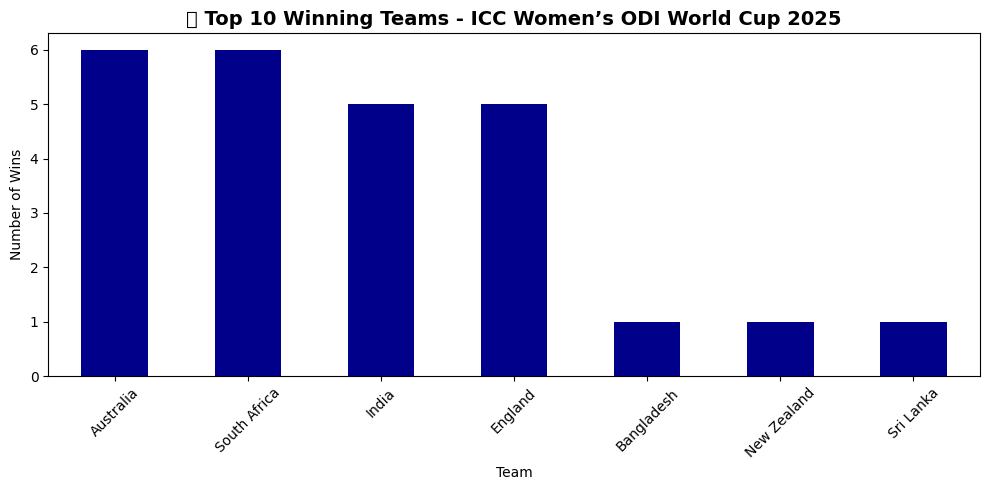

In [13]:
# --- 1. Top Winning Teams ---
plt.figure(figsize=(10,5))
df['winning_team'].value_counts().head(10).plot(kind='bar', color='darkblue')
plt.title('🏆 Top 10 Winning Teams - ICC Women’s ODI World Cup 2025', fontsize=14, fontweight='bold')
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


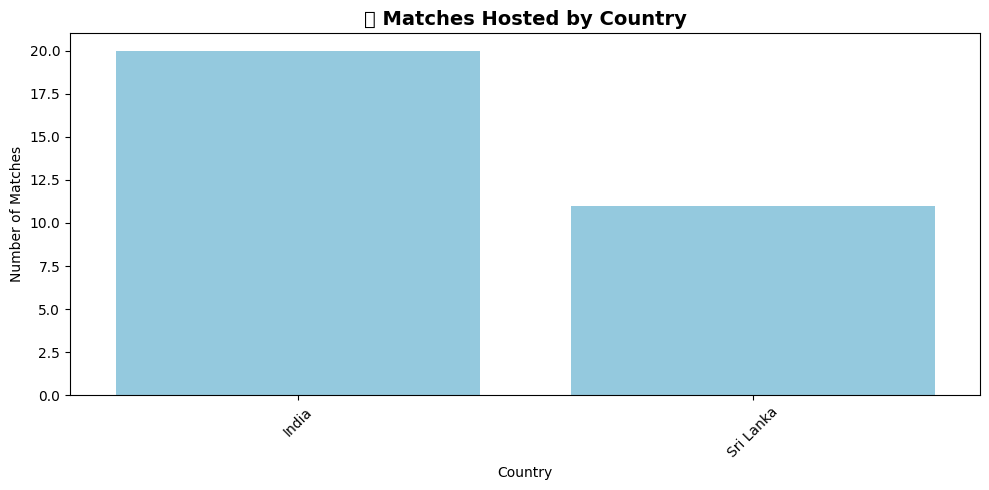

In [14]:
# --- 2. Match Venues by Country ---
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='venue_country', order=df['venue_country'].value_counts().index, color='skyblue')
plt.title('🌍 Matches Hosted by Country', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

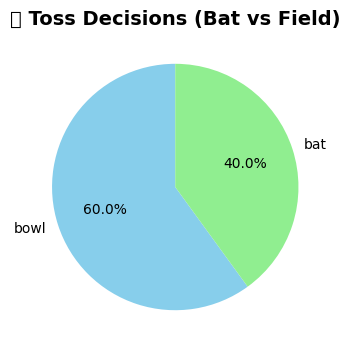

In [15]:
# --- 3. Toss Decisions ---
plt.figure(figsize=(6,4))
df['toss_decision'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue','lightgreen'], startangle=90)
plt.title('🪙 Toss Decisions (Bat vs Field)', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()


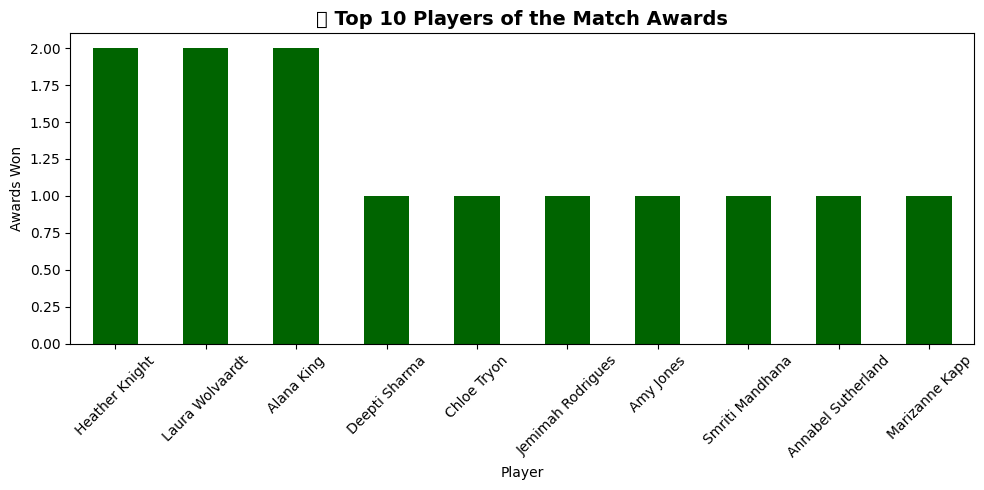

In [16]:

# --- 4. Top 10 Players of the Match (POTM) ---
plt.figure(figsize=(10,5))
df['POTM'].value_counts().head(10).plot(kind='bar', color='darkgreen')
plt.title('🌟 Top 10 Players of the Match Awards', fontsize=14, fontweight='bold')
plt.xlabel('Player')
plt.ylabel('Awards Won')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

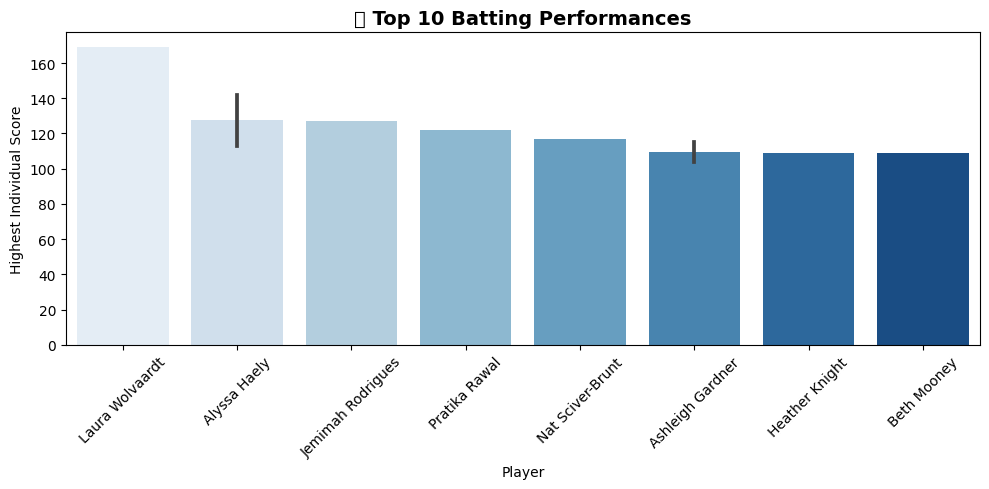

In [17]:
# --- 5. Top Scorers by Highscore ---
plt.figure(figsize=(10,5))
sns.barplot(data=df.sort_values(by='highscore', ascending=False).head(10),
            x='top_scorer', y='highscore', palette='Blues')
plt.title('🔥 Top 10 Batting Performances', fontsize=14, fontweight='bold')
plt.xlabel('Player')
plt.ylabel('Highest Individual Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

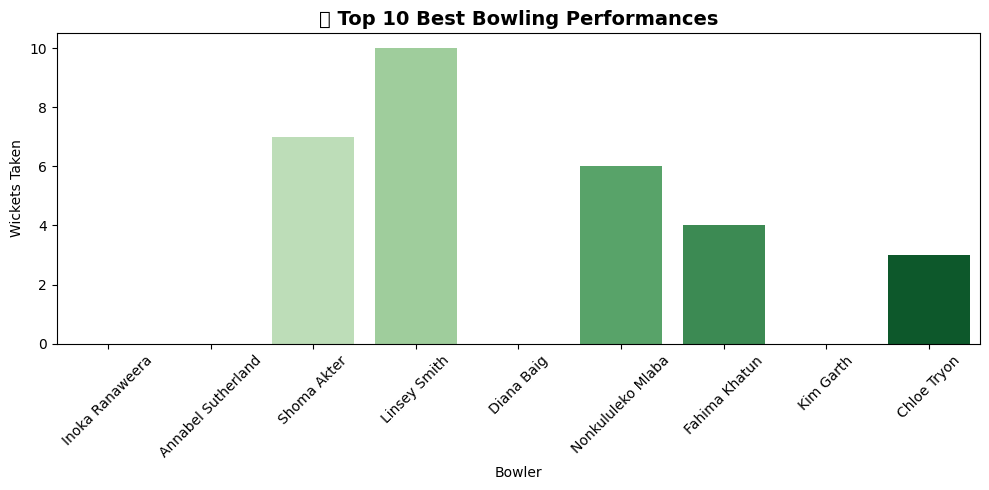

In [18]:
# --- 6. Best Bowling Performances ---
plt.figure(figsize=(10,5))
sns.barplot(data=df.head(10), x='best_bowling', y='wb_wickets', palette='Greens')
plt.title('🎯 Top 10 Best Bowling Performances', fontsize=14, fontweight='bold')
plt.xlabel('Bowler')
plt.ylabel('Wickets Taken')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

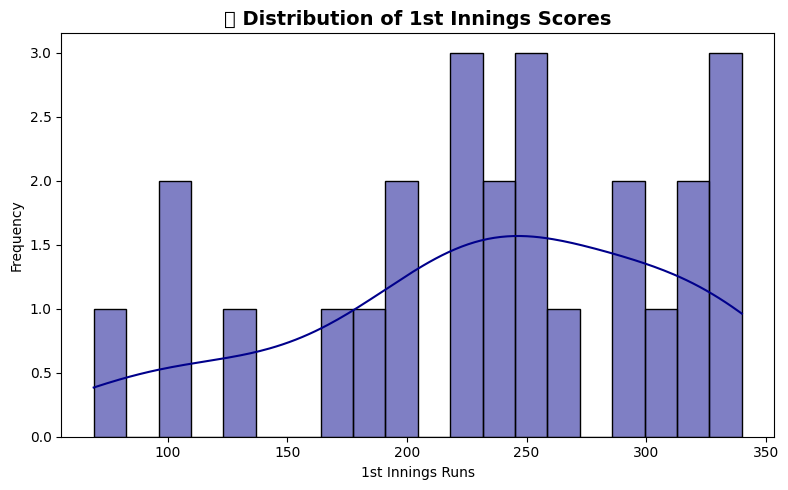

In [19]:
# --- 7. Distribution of First Innings Scores ---
plt.figure(figsize=(8,5))
sns.histplot(df['1st_score'], bins=20, color='darkblue', kde=True)
plt.title('📊 Distribution of 1st Innings Scores', fontsize=14, fontweight='bold')
plt.xlabel('1st Innings Runs')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

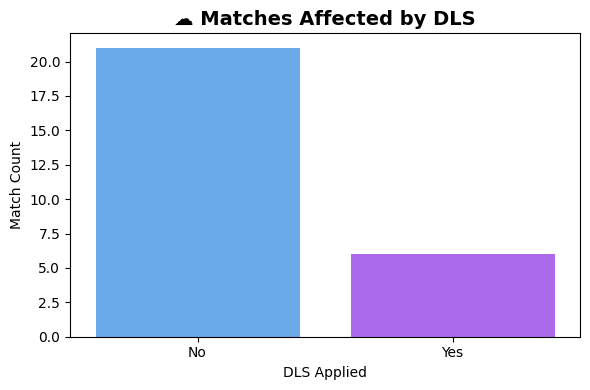

In [20]:
# --- 8. Matches Affected by DLS Method ---
plt.figure(figsize=(6,4))
dls_counts = df['DLS_involved'].value_counts()
sns.barplot(x=dls_counts.index, y=dls_counts.values, palette='cool')
plt.title('☁️ Matches Affected by DLS', fontsize=14, fontweight='bold')
plt.xlabel('DLS Applied')
plt.ylabel('Match Count')
plt.tight_layout()
plt.show()

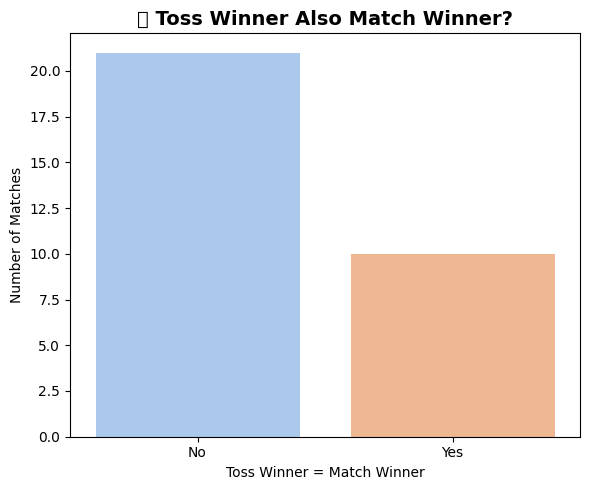

In [21]:
# --- 9. Toss Winner vs Match Winner Relationship ---
plt.figure(figsize=(6,5))

# Create a new column to check if toss winner also won the match
df['toss_equals_match'] = np.where(df['toss_winner'] == df['winning_team'], 'Yes', 'No')

sns.countplot(data=df, x='toss_equals_match', palette='pastel')
plt.title('🪙 Toss Winner Also Match Winner?', fontsize=14, fontweight='bold')
plt.xlabel('Toss Winner = Match Winner')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()


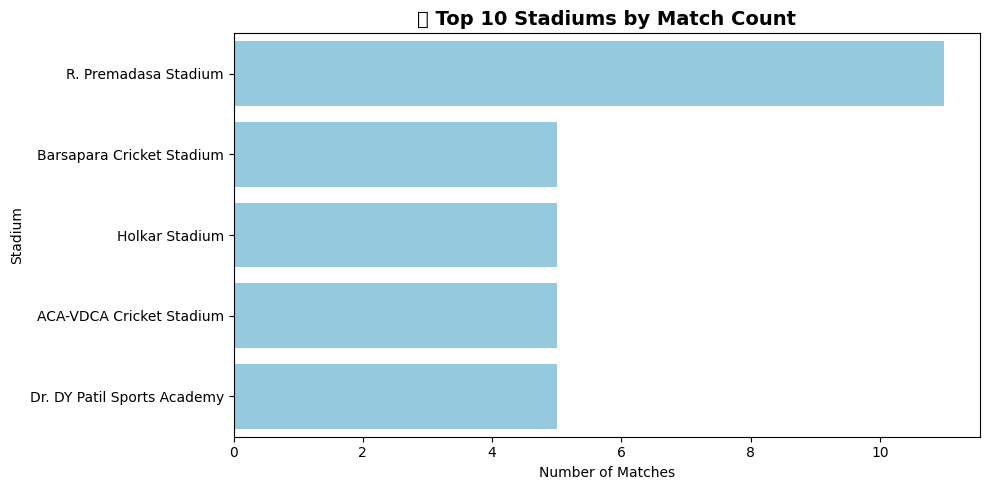

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='venue_stadium', order=df['venue_stadium'].value_counts().head(10).index, color='skyblue')
plt.title('🏟️ Top 10 Stadiums by Match Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Matches')
plt.ylabel('Stadium')
plt.tight_layout()
plt.show()

## Data visualizations

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [24]:
df = df.drop(['match_id', 'date'], axis=1)
df = df.fillna('Unknown')

In [25]:
# --- 1. Label Encoding with Fix for Mixed Types ---
from sklearn.preprocessing import LabelEncoder
import numpy as np

le = LabelEncoder()

# Convert all object columns to string type (handle NaNs)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str)
        df[col] = le.fit_transform(df[col])

In [26]:
X = df.drop('winning_team', axis=1)
y = df['winning_team']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(),
    'Gradient Boosting': GradientBoostingClassifier()
}


In [29]:
accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    accuracies[name] = round(acc, 2)
    print(f"{name} Accuracy: {acc:.2f}%")


Logistic Regression Accuracy: 42.86%
Decision Tree Accuracy: 28.57%
Random Forest Accuracy: 28.57%
K-Nearest Neighbors Accuracy: 42.86%
Support Vector Machine Accuracy: 28.57%
Gradient Boosting Accuracy: 42.86%


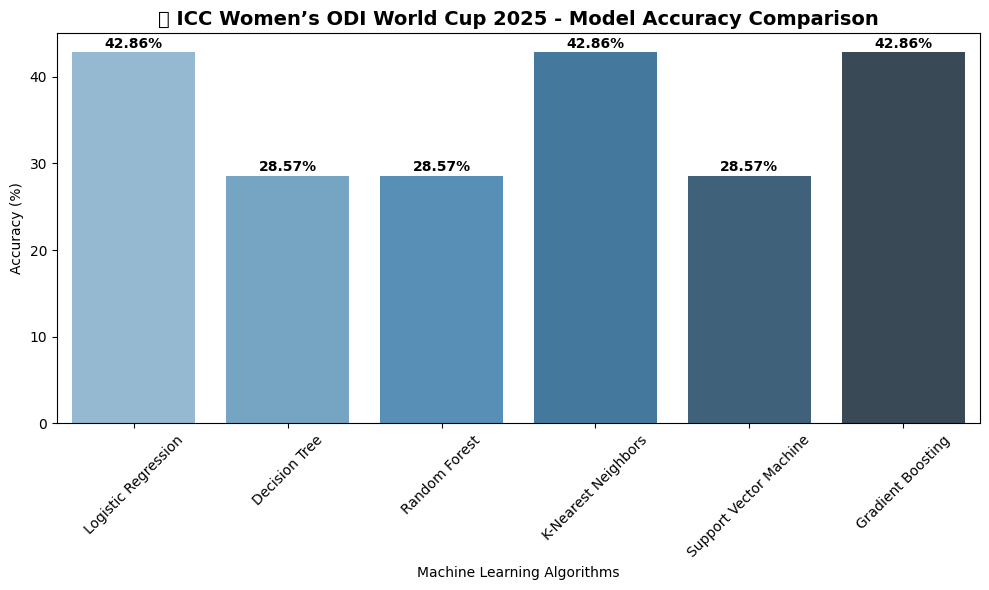

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='Blues_d')
plt.title("🏏 ICC Women’s ODI World Cup 2025 - Model Accuracy Comparison", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy (%)")
plt.xlabel("Machine Learning Algorithms")
plt.xticks(rotation=45)
for i, v in enumerate(accuracies.values()):
    plt.text(i, v + 0.5, f"{v}%", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


In [31]:
best_model = max(accuracies, key=accuracies.get)
print(f"\n🌟 Best Performing Model: {best_model} with Accuracy = {accuracies[best_model]}%")


🌟 Best Performing Model: Logistic Regression with Accuracy = 42.86%


## Thank you...pls upvote